<a href="https://colab.research.google.com/github/Vedika-Hore/python-micro-project/blob/main/Task_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
  print(fn)

Saving car_price_dataset.csv to car_price_dataset.csv
car_price_dataset.csv


In [2]:
filepath=("/content/car_price_dataset.csv")
df=pd.read_csv(filepath)
print(df)


           Brand     Model  Year  Engine_Size Fuel_Type    Transmission  \
0            Kia       Rio  2020          4.2    Diesel          Manual   
1      Chevrolet    Malibu  2012          2.0    Hybrid       Automatic   
2       Mercedes       GLA  2020          4.2    Diesel       Automatic   
3           Audi        Q5  2023          2.0  Electric          Manual   
4     Volkswagen      Golf  2003          2.6    Hybrid  Semi-Automatic   
...          ...       ...   ...          ...       ...             ...   
9995         Kia    Optima  2004          3.7    Diesel  Semi-Automatic   
9996   Chevrolet    Impala  2002          1.4  Electric       Automatic   
9997         BMW  3 Series  2010          3.0    Petrol       Automatic   
9998        Ford  Explorer  2002          1.4    Hybrid       Automatic   
9999  Volkswagen    Tiguan  2001          2.1    Diesel          Manual   

      Mileage  Doors  Owner_Count  Price  
0      289944      3            5   8501  
1        5356

In [5]:
df.head(10)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
5,Toyota,Camry,2007,2.7,Petrol,Automatic,157889,4,4,7242
6,Honda,Civic,2010,3.4,Electric,Automatic,139584,3,1,11208
7,Kia,Sportage,2001,4.7,Electric,Semi-Automatic,157495,2,2,7950
8,Kia,Sportage,2014,2.6,Hybrid,Manual,98700,3,4,9926
9,Toyota,RAV4,2005,3.1,Petrol,Manual,107724,2,5,6545


In [ ]:
  #Summery

  # The Car Price Prediction dataset contains information about different cars and their features,
  # which are used to predict the selling price of a car. It includes both numerical features (such
  # as year, kilometers driven, engine size, mileage, power, and number of seats) and categorical
  # features (such as car name, fuel type, transmission, seller type, and owner). The target variable
  # is Selling_Price (or Price, depending on the dataset), making this a supervised machine learning regression problem.

In [6]:
missing=df.isnull().sum()
missing_per=(missing / len(df)) * 100
print("Missing value percentage:")
missing_per


Missing value percentage:


,0
Brand,0.0
Model,0.0
Year,0.0
Engine_Size,0.0
Fuel_Type,0.0
Transmission,0.0
Mileage,0.0
Doors,0.0
Owner_Count,0.0
Price,0.0


In [16]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
for col in num_cols:
  df[num_cols]=df[num_cols].fillna(df[num_cols].mean())
  df[num_cols]


In [24]:
cat_cols=df.select_dtypes(include=["object"]).columns
for col in num_cols:
  df[cat_cols]=df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
  df[cat_cols]


In [25]:
print("Duplicate value:",df.duplicated().sum())
df=df.drop_duplicates()
print("New Shape:",df.shape)

Duplicate value: 0
New Shape: (10000, 10)


In [ ]:
'''Observations:

Checked each column for missing values and calculated the percentage of missing data.
Numerical missing values were filled using the median, while categorical missing values
were filled using the mode. (Alternatively, rows with missing values can be dropped if they are very few.)
Duplicate rows were identified using duplicated() and removed using drop_duplicates().

Steps Taken:-

1]Checked missing values in every column.
2]Calculated the percentage of missing values.
3]Filled missing values (or removed rows containing them).
4]Checked for duplicate records.
5]Removed duplicate rows to improve data quality.'

In [32]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


In [ ]:
  # Observations

  # 1]The selling prices vary widely, indicating that the dataset contains both low-priced and high-priced cars.
  # 2]If the mean price is greater than the median price, the target variable is positively (right) skewed due to a few expensive cars.
  # 3]The difference between the minimum and maximum selling prices shows a large price range in the dataset.
  # 4]The standard deviation of the selling price is relatively high, suggesting that car prices are spread over a wide range rather
  #   than being concentrated around the average.

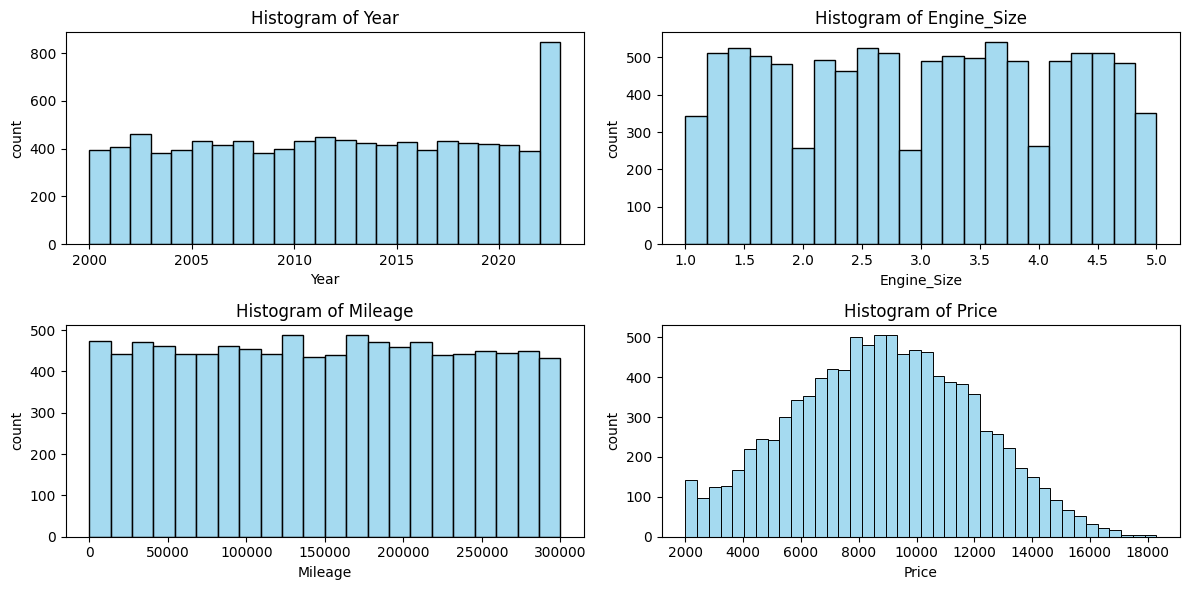

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
sns.histplot(df["Year"],color="skyblue",edgecolor="black")
plt.title("Histogram of Year")
plt.xlabel("Year")
plt.ylabel("count")

plt.subplot(2,2,2)
sns.histplot(df["Engine_Size"],color="skyblue",edgecolor="black")
plt.title("Histogram of Engine_Size")
plt.xlabel("Engine_Size")
plt.ylabel("count")

plt.subplot(2,2,3)
sns.histplot(df["Mileage"],color="skyblue",edgecolor="black")
plt.title("Histogram of Mileage")
plt.xlabel("Mileage")
plt.ylabel("count")

plt.subplot(2,2,4)
sns.histplot(df["Price"],color="skyblue",edgecolor="black")
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("count")

plt.tight_layout()


In [33]:
df.head(5)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [38]:
print("categarical column:")
df.select_dtypes(include=['object'])

categarical column:


,Brand,Model,Fuel_Type,Transmission
0,Kia,Rio,Diesel,Manual
1,Chevrolet,Malibu,Hybrid,Automatic
2,Mercedes,GLA,Diesel,Automatic
3,Audi,Q5,Electric,Manual
4,Volkswagen,Golf,Hybrid,Semi-Automatic
...,...,...,...,...
9995,Kia,Optima,Diesel,Semi-Automatic
9996,Chevrolet,Impala,Electric,Automatic
9997,BMW,3 Series,Petrol,Automatic
9998,Ford,Explorer,Hybrid,Automatic


/tmp/ipykernel_1851/1448033767.py:29: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


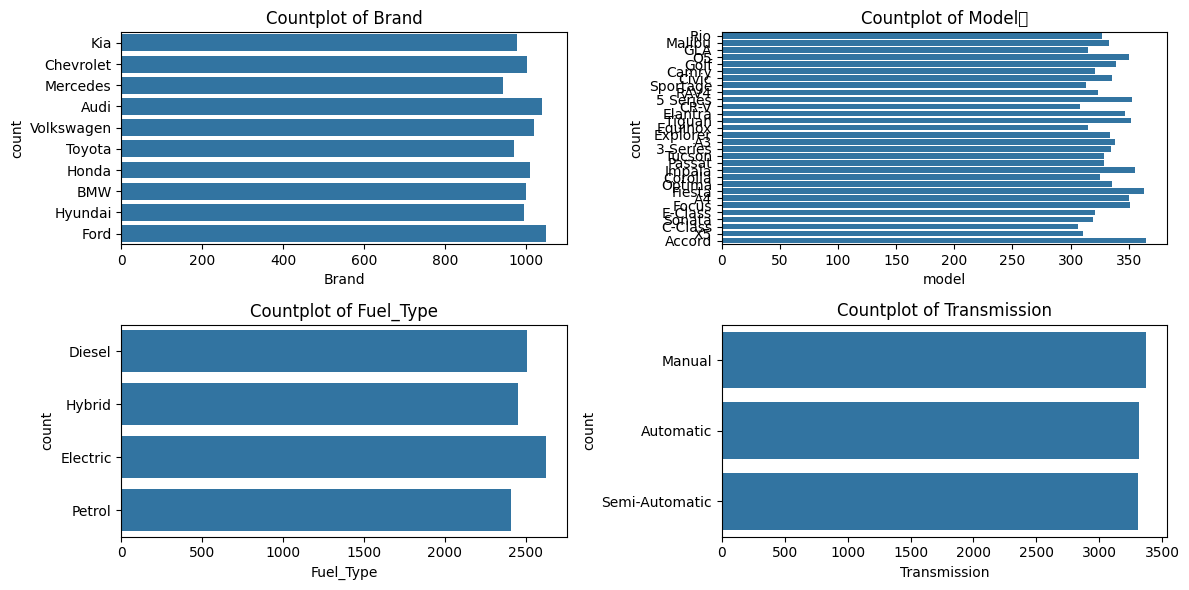

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
sns.countplot(df["Brand"])
plt.title("Countplot of Brand")
plt.xlabel("Brand")
plt.ylabel("count")

plt.subplot(2,2,2)
sns.countplot(df["Model"])
plt.title("Countplot of Model	")
plt.xlabel("model")
plt.ylabel("count")

plt.subplot(2,2,3)
sns.countplot(df["Fuel_Type"])
plt.title("Countplot of Fuel_Type")
plt.xlabel("Fuel_Type")
plt.ylabel("count")

plt.subplot(2,2,4)
sns.countplot(df["Transmission"])
plt.title("Countplot of Transmission")
plt.xlabel("Transmission")
plt.ylabel("count")

plt.tight_layout()
plt.show()

In [ ]:
  # Business / Domain-Related Insights:-
  # 1]Fuel Type: Petrol cars are usually the most common, indicating higher demand and availability in the used car market.
  # 2]Transmission: Manual transmission cars generally outnumber automatic cars because they are more affordable and have lower maintenance costs.
  # 3]model:The model feature is important for predicting car prices because different models have different market values, features, and demand.
  # 4]Brand: Some car brands or models appear much more frequently than others, indicating their popularity in the market

Text(0.5, 1.0, 'Correlation heatmap')

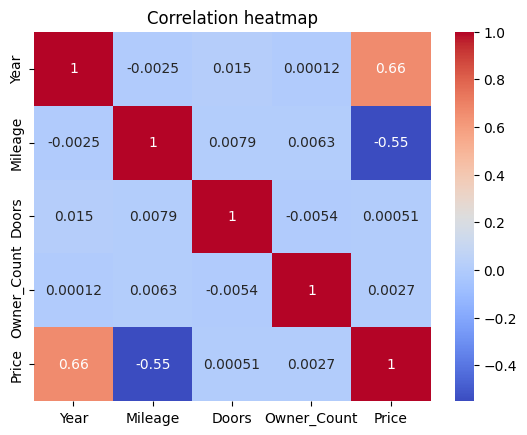

In [50]:
corr = df.select_dtypes(include=['int64']).corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation heatmap")

In [ ]:
  # Observations
  # 1]The target variable (Price/Selling Price) has a strong positive correlation with features such as engine size, max power, and year,
  # 2]indicating that newer cars with larger engines and higher power generally have higher selling prices.
  # 3]Kilometers driven (km_driven) usually has a negative correlation with the selling price, meaning cars driven more tend to have lower resale values.
  # 4]Features like engine and max_power are often positively correlated with each other because vehicles with larger engines usually produce more power.
  #   Some features may show weak or near-zero correlation with the target variable, indicating they have little direct linear influence on car price

In [58]:
print("Independent Feature:")
X = df.drop('Price',axis=1)
X

Independent Feature:


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3
...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1


In [59]:
print("Dependent Feature:")
Y=df["Price"]
Y

Dependent Feature:


,Price
0,8501
1,12092
2,11171
3,11780
4,2867
...,...
9995,8884
9996,6240
9997,9866
9998,4084


In [ ]:
#Independent Features (X): These are the car characteristics such as year, kilometers driven, fuel type, transmission, engine size, mileage, and doors.
#They are used as inputs to predict the price of a car.

#Dependent Feature (y): The price (or selling_price) is the target variable because it is the value we want the machine learning model to predict.
#Since the price is a continuous numeric value, this is a Regression problem

In [60]:
encode_df=pd.get_dummies(X)
encode_df=encode_df.astype(int)
encode_df



,Year,Engine_Size,Mileage,Doors,Owner_Count,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,...,Model_Tiguan,Model_Tucson,Model_X5,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Transmission_Semi-Automatic
0,2020,4,289944,3,5,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,2012,2,5356,2,3,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
2,2020,4,231440,4,2,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,2023,2,160971,2,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,2003,2,286618,3,3,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2004,3,5794,2,4,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
9996,2002,1,168000,2,1,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
9997,2010,3,86664,5,1,0,1,0,0,0,...,0,0,0,0,0,0,1,1,0,0
9998,2002,1,225772,4,1,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0


In [62]:
print("Before Encoding:")
df.head(2)

Before Encoding:


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092


In [65]:
print("After Encoding:")
encode_df.head(2)

After Encoding:


,Year,Engine_Size,Mileage,Doors,Owner_Count,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,...,Model_Tiguan,Model_Tucson,Model_X5,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Transmission_Semi-Automatic
0,2020,4,289944,3,5,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,2012,2,5356,2,3,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0


In [ ]:
# Explanation of Encoding Choice
# One-Hot Encoding was used because the categorical variables (such as fuel, transmission, seller type, and owner) have no natural numerical order.
# It converts each category into a separate binary (0/1) column, allowing machine learning algorithms to process the data correctly.
# The parameter drop_first=True removes one category from each feature to avoid dummy variable trap (multicollinearity), making the model more efficient.

In [73]:
from sklearn.preprocessing import StandardScaler
num_cols=["Year","Engine_Size","Mileage","Doors"]
scaler=StandardScaler()
encode_df[num_cols] = scaler.fit_transform(encode_df[num_cols])
print("First 5 rows of the scaled features:")
encode_df.head()


First 5 rows of the scaled features:


,Year,Engine_Size,Mileage,Doors,Owner_Count,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,...,Model_Tiguan,Model_Tucson,Model_X5,Fuel_Type_Diesel,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Transmission_Semi-Automatic
0,1.226021,1.281283,1.630075,-0.447821,5,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0.066156,-0.483813,-1.666895,-1.348689,3,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
2,1.226021,1.281283,0.952303,0.453046,2,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,1.660970,-0.483813,0.135915,-1.348689,1,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,-1.238692,-0.483813,1.591543,-0.447821,3,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
